# V52: Trend Override Strategy (LQ45)

Notebook ini memperkenalkan logika **"Smart Hold"** atau **Trend Override** untuk mengatasi kelemahan AI yang terlalu cepat keluar (False Bear) saat pasar sedang Rally kuat.

### Masalah di V51:
AI sering memberikan sinyal "Bear" (Risk OFF) di tengah tren naik yang kuat, menyebabkan strategi ketinggalan keuntungan besar (Opportunity Loss) yang didapat oleh strategi Statis.

### Solusi V52 (Trend Override):
Kita menambahkan aturan filter sederhana:
**"Hanya boleh keluar ke Cash (Risk OFF) jika AI menyuruh Bear DAN Tren Pasar benar-benar patah."**

Logika Keputusan:
1.  **Cek Sinyal AI**: Apakah Probabilitas > Threshold?
2.  **Cek Tren Pasar**: Apakah Harga Indeks LQ45 > SMA-nya (misal SMA-50)?
3.  **Final Signal**:
    *   Jika AI = **Bull**, maka **RISK ON**.
    *   Jika AI = **Bear**, TAPI Tren Pasar = **Strong Uptrend**, maka **OVERRIDE** -> Tetap **RISK ON**.
    *   Hanya jika AI = **Bear** DAN Tren Pasar = **Downtrend**, baru **RISK OFF** (Cash).

Ini akan membiarkan kita "menunggangi ombak" (Ride the Wave) sampai tren benar-benar berakhir, sambil tetap terlindungi jika pasar crash parah (karena saat crash, harga pasti tembus ke bawah SMA).

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
import xgboost as xgb
from sklearn.metrics import fbeta_score
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

# --- 1. Load Data ---
file_path = 'data_lq45_2023_2025.xlsx'
if not os.path.exists(file_path):
    file_path = 'dataset_2023_2025.xlsx'

data = pd.read_excel(file_path, index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)
# Reconstruct Market Index for Trend Calculation
market_index = (1 + market_return).cumprod() * 100

print(f"Data Loaded: {len(data)} rows")

Data Loaded: 712 rows


In [2]:
# --- 2. AI Training (Standard V47) ---
features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['Mom_50'] = market_return.rolling(window=50).mean()

sma5 = market_return.rolling(window=5).mean()
sma20 = market_return.rolling(window=20).mean()
target = (sma5 > sma20).astype(int).shift(-5).reindex(features.index).fillna(0)

X_train = features.loc[features.index.year <= 2024].dropna()
y_train = target.loc[X_train.index]
X_test = features.loc[features.index.year == 2025]

xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

train_probs = xgb_model.predict_proba(X_train)[:, 1]
opt_t = np.linspace(0.3, 0.7, 41)[np.argmax([fbeta_score(y_train, (train_probs >= t).astype(int), beta=0.5) for t in np.linspace(0.3, 0.7, 41)])]
test_probs = pd.Series(xgb_model.predict_proba(X_test)[:, 1], index=X_test.index)

print(f"Optimized Threshold: {opt_t:.2f}")

Optimized Threshold: 0.54


In [3]:
# --- 3. Core Logic: Trend Override Simulation ---

def get_mis_assets(returns_window, correlation_threshold=0.4):
    corr_mat = returns_window.corr()
    G = nx.Graph()
    assets = returns_window.columns
    G.add_nodes_from(assets)
    for i in range(len(assets)):
        for j in range(i+1, len(assets)):
            if abs(corr_mat.iloc[i, j]) > correlation_threshold:
                G.add_edge(assets[i], assets[j])
    return list(nx.approximation.maximum_independent_set(G))

def optimize_markowitz(selected_returns):
    if len(selected_returns.columns) == 0: return {}
    if len(selected_returns.columns) == 1: return {selected_returns.columns[0]: 1.0}
    
    mu, sigma = selected_returns.mean() * 252, selected_returns.cov() * 252
    num_assets = len(mu)

    def objective(w):
        ret = np.sum(w * mu)
        risk = np.sqrt(np.dot(w.T, np.dot(sigma, w)))
        if risk < 0.0001: return 0
        return -(ret / risk)

    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0, 1) for _ in range(num_assets))
    init_guess = [1./num_assets] * num_assets

    res = minimize(objective, init_guess, method='SLSQP', bounds=bounds, constraints=constraints)
    return dict(zip(selected_returns.columns, res.x)) if res.success else {}

def run_simulation_trend_override(test_dates, returns, ai_probs, threshold, market_idx, 
                                  override_ma=None, # e.g., 20 or 50. If None, no override.
                                  fee=0.0025, 
                                  g_lookback=60, 
                                  rebal_period=20, 
                                  turnover_buffer=0.05):
    val = 100.0
    history = [val]
    dates = [test_dates[0]]
    
    current_weights = {} 
    risk_status = False 
    
    days_since_rebal = 999
    
    # Calculate Moving Average for Trend Override check
    if override_ma:
        market_ma = market_idx.rolling(window=override_ma).mean()
    
    # To debug override events
    override_count = 0
    
    for i, date in enumerate(test_dates[:-1]):
        prev_risk_status = risk_status
        prob = ai_probs.loc[date]
        
        # 1. Base AI Signal
        ai_signal = False
        buffer = 0.05
        # Use standard hysteresis logic
        if not risk_status and prob > (threshold + buffer): ai_signal = True
        elif risk_status and prob < (threshold - buffer): ai_signal = False
        else: ai_signal = risk_status # Keep current state
        
        # 2. Trend Override Logic
        final_signal = ai_signal
        
        if override_ma:
            current_price = market_idx.loc[date]
            ma_price = market_ma.loc[date]
            
            is_uptrend = (current_price > ma_price)
            
            if ai_signal == False and is_uptrend:
                # OVERRIDE: AI says Sell, but Market is in Uptrend -> FORCE HOLD
                final_signal = True
                if risk_status == True: # Only count if we successfully prevented a sell
                     override_count += 0 # Just for tracking, logic is simple assignment
        
        risk_status = final_signal
        regime_changed = (risk_status != prev_risk_status)
        
        # --- 3. Portfolio Management (Same as V51) ---
        target_weights = current_weights.copy()
        
        if not risk_status:
            # Risk OFF
            if regime_changed or 'CASH' not in current_weights or current_weights.get('CASH', 0) < 0.99:
                target_weights = {'CASH': 1.0}
                days_since_rebal = 0
        else:
            # Risk ON
            if regime_changed or days_since_rebal >= rebal_period:
                loc_idx = returns.index.get_loc(date)
                window_rets = returns.iloc[loc_idx-g_lookback:loc_idx]
                selected = get_mis_assets(window_rets)
                optimized_weights = optimize_markowitz(window_rets[selected])
                
                all_keys = set(list(optimized_weights.keys()) + list(current_weights.keys()))
                turnover_est = sum(abs(optimized_weights.get(k, 0) - current_weights.get(k, 0)) for k in all_keys)
                
                if regime_changed or turnover_est > turnover_buffer:
                    target_weights = optimized_weights
                    days_since_rebal = 0
            
            days_since_rebal += 1

        # --- 4. Execution ---
        all_keys_exec = set(list(target_weights.keys()) + list(current_weights.keys()))
        turnover_actual = sum(abs(target_weights.get(k, 0) - current_weights.get(k, 0)) for k in all_keys_exec)
        
        if turnover_actual > 0.001:
            cost = val * turnover_actual * fee
            val -= cost
        
        next_date = test_dates[i+1]
        day_ret = 0
        new_weights_drifted = {}
        
        if 'CASH' in target_weights and target_weights['CASH'] > 0.99:
            day_ret = 0
            new_weights_drifted = {'CASH': 1.0}
        else:
            for asset, w in target_weights.items():
                if asset in returns.columns:
                    r = returns.loc[next_date, asset]
                    # Use 0 if asset missing (unlikely with dropna)
                    r_asset = r if not pd.isna(r) else 0
                    day_ret += w * r_asset
                    new_weights_drifted[asset] = w * (1 + r_asset)
                else:
                    new_weights_drifted[asset] = w
            
            total_w = sum(new_weights_drifted.values()) if new_weights_drifted else 0
            if total_w > 0:
                new_weights_drifted = {k: v/total_w for k, v in new_weights_drifted.items()}
        
        val *= (1 + day_ret)
        history.append(val)
        dates.append(next_date)
        current_weights = new_weights_drifted
    
    return pd.DataFrame({'Portfolio_Value': history}, index=dates)

Running Static (Risk Always ON)...
Running Standard AI (No Override)...
Running Trend Override AI (SMA 20)...
Running Trend Override AI (SMA 50)...


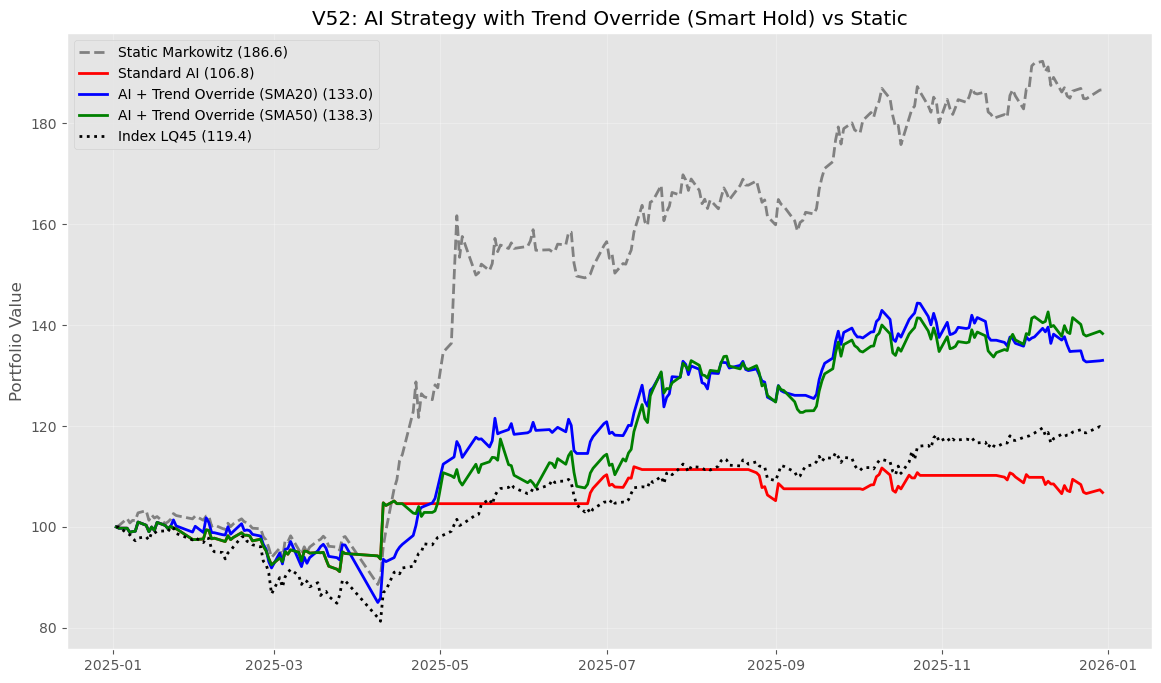


=== Performance ROI & Risk ===
                      Strategy   Return %   Max DD %
0             Static Markowitz  86.619321 -14.178491
3  AI + Trend Override (SMA50)  38.317589  -9.723880
2  AI + Trend Override (SMA20)  33.005279 -16.487169
4                   Index LQ45  19.435320 -18.695217
1                  Standard AI   6.824827  -9.723880


In [4]:
# --- 4. Run Scenarios ---
test_dates = X_test.index
fee_rate = 0.0025

results = {}

# 1. Static (Benchmark)
print("Running Static (Risk Always ON)...")
# Mock standard AI signal to always be > threshold for static simulation, 
# or just use specific static logic. To be clean, let's reuse func with override_ma=None but logic hack?
# Easier: Just pass overrides that force True. But function internal logic uses AI probs.
# Let's use a "Static" Prob series that is always 1.0
static_probs = pd.Series(1.0, index=test_probs.index)
res_static = run_simulation_trend_override(test_dates, returns, static_probs, 0.5, market_index, 
                                           override_ma=None, fee=fee_rate)
results['Static Markowitz'] = res_static['Portfolio_Value']

# 2. Standard AI (V47) - No Override
print("Running Standard AI (No Override)...")
res_standard = run_simulation_trend_override(test_dates, returns, test_probs, opt_t, market_index, 
                                             override_ma=None, fee=fee_rate)
results['Standard AI'] = res_standard['Portfolio_Value']

# 3. Trend Override AI (SMA 20)
print("Running Trend Override AI (SMA 20)...")
res_trend20 = run_simulation_trend_override(test_dates, returns, test_probs, opt_t, market_index, 
                                            override_ma=20, fee=fee_rate)
results['AI + Trend Override (SMA20)'] = res_trend20['Portfolio_Value']

# 4. Trend Override AI (SMA 50)
print("Running Trend Override AI (SMA 50)...")
res_trend50 = run_simulation_trend_override(test_dates, returns, test_probs, opt_t, market_index, 
                                            override_ma=50, fee=fee_rate)
results['AI + Trend Override (SMA50)'] = res_trend50['Portfolio_Value']

# 5. Benchmark Index
benchmark = market_index.reindex(res_static.index).fillna(method='ffill')
# Normalize benchmark to start at 100 on test start date
benchmark = benchmark / benchmark.iloc[0] * 100
results['Index LQ45'] = benchmark

# --- 5. Visualization ---
plt.figure(figsize=(14, 8))

colors = ['gray', 'red', 'blue', 'green', 'black']
styles = ['--', '-', '-', '-', ':']

for (name, series), color, style in zip(results.items(), colors, styles):
    plt.plot(series.index, series, label=f"{name} ({series.iloc[-1]:.1f})", color=color, linestyle=style, linewidth=2)

plt.title('V52: AI Strategy with Trend Override (Smart Hold) vs Static')
plt.ylabel('Portfolio Value')
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig('v52_trend_override_results.png')
plt.show()

# Summary
summary = []
for name, series in results.items():
    total_ret = (series.iloc[-1] - 100)
    peak = series.cummax()
    dd = (series - peak) / peak
    max_dd = dd.min() * 100
    summary.append({'Strategy': name, 'Return %': total_ret, 'Max DD %': max_dd})

df_summary = pd.DataFrame(summary).sort_values('Return %', ascending=False)
print("\n=== Performance ROI & Risk ===")
print(df_summary)

df_results = pd.DataFrame(results)
df_results.to_excel('v52_trend_override_results.xlsx')